# 06 Commong Design Building Blocks
- Adding new activation functions
- Inserting new layers to improve training
- Skipping layers as a useful design pattern
- Combining new activations, layers and skips into new approaches
## Creating a baseline with the FashionMINST dataset for the improvements comparisons

In [1]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
#from idlmam import *
from sklearn.metrics import accuracy_score

In [2]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #import all my functions

print(" dl_utils loaded")

# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = False  # False is better for RNNs with variable input sizes, True for CNNs

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')

 dl_utils loaded
Device available: cuda


/home/efrain/Documents/Bio-AI-foundations/DL_utils_EZA/dl_utils.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
# Load the Fashion-MNIST dataset
train_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=True, transform=transforms.ToTensor(), download=False)
test_fmnist_data = torchvision.datasets.FashionMNIST("./data", train=False, transform=transforms.ToTensor(), download=False)

In [ ]:
# Data loaders
train_fmnist_loader = DataLoader(train_fmnist_data, 
                                 batch_size=256, 
                                 shuffle=True,
                                 num_workers=4,
                                 pin_memory=True,
                                 persistent_workers=True,
                                 drop_last=True
)

test_fmnist_loader = DataLoader(test_fmnist_data, 
                                batch_size=256*2,
                                shuffle=False,
                                num_workers=4,
                                persistent_workers=True,
                                pin_memory=True
)

In [8]:
# Define the Hyperparameters for the baseline model
W = 28          # Width of the images from FashionMNIST
H = 28          # Height of the images from FashionMNIST
D = 28*28       # Number of values in the input. This value helps to determine size of subsequent layers: 28*28 images
n = 256         # Hidden layers size
C = 1           # Channels in the input
n_filters = 32  # Number of filters (kernels) per convolutional layer
classes = 10    # Number of clases in the data set

loss_function = nn.CrossEntropyLoss()

In [6]:
# Define a FULLY CONNECTED NETWORK baseline model
fc_model_base = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), # First hidden layer
    nn.Tanh(),
    *[nn.Sequential(nn.Linear(n, n), nn.Tanh()) for _ in range(5)],  # "list unpacking", each reamining layer has the same
                                                                     # input/output sizes.
    nn.Linear(n, classes)
)

In [7]:
# Define the CNN baseline model
cnn_model_base = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(2*n_filters,4*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Conv2d(4*n_filters,4*n_filters, 3, padding=1),
    nn.Tanh(),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [ ]:
# Train the Fully Connected Network baseline
fc_model_base_results = train_network_EZA(fc_model_base,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 100/100 [05:09<00:00,  3.09s/it]


In [ ]:
# Train the CNN baseline

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

# Train the Fully Connected Network baseline
cnn_model_base_results = train_network_EZA(cnn_model_base,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 100/100 [05:39<00:00,  3.40s/it]


(0.0, 30.0)

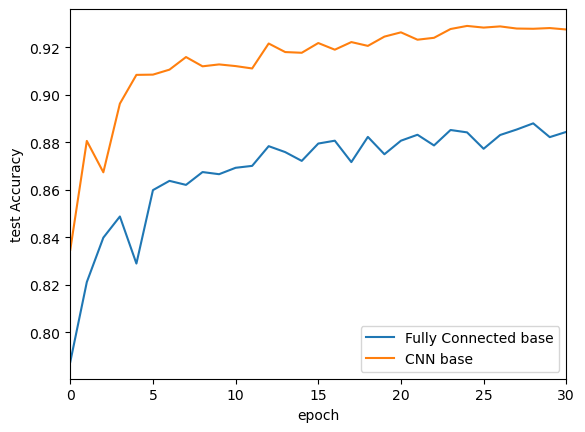

In [17]:
# 
# Plot the results for comparison
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_base_results, label='Fully Connected base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
plt.xlim(0,30)

## Better Activation Functions
### Vanishing gradients problem of Tanh and sigmoid
When the gradient function gives values close to 0, giving no learing

<Axes: >

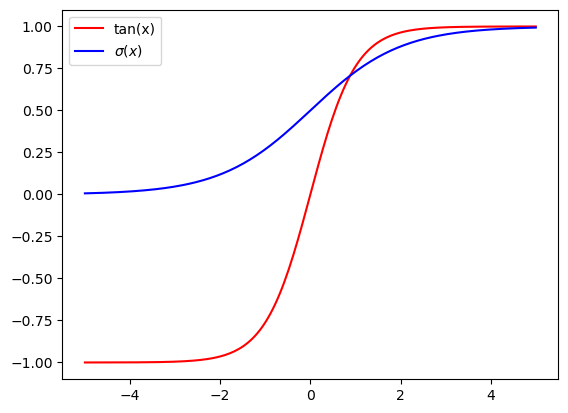

In [20]:
# Plot the sigmoid and Tanh functions
def sigmoid(x):
    return np.exp(activation_input)/(np.exp(activation_input)+1)

activation_input =  np.linspace(-5, 5, num=200)
tanh_activation = np.tanh(activation_input)
sigmoid_activation = sigmoid(activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label='$\sigma(x)$')

<Axes: >

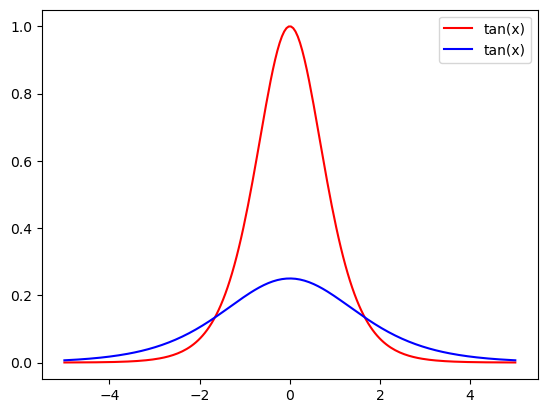

In [22]:
# Plot the derivatives of the Tanh and sigmoid fucntions to see the saturation effect
def tanh_deriv(x):
    return 1.0 - np.tanh(x)**2
def sigmoid_deriv(x):
    return sigmoid(x)*(1-sigmoid(x))

tanh_deriv = tanh_deriv(activation_input)
sigmoid_deriv = sigmoid_deriv(activation_input)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label='tan(x)')

### Avoiding Vanishing Gradients with: Rectified Linear Units (ReLU)
Definition:    $ReLU(x) = max(0,x)$\
Derivative: $ReLU'(x) = 1, if x > 0; 0, otherwise$

Another ReLU variation takes a factor alpha to avoid inactivation\
Definition:   $LeakyReLU(x) = max(\alpha*x,x)$\
Derivative:   $LeakyRELU'(x) = 1, if x > 0;  \alpha$, otherwise

(-1.2, 1.2)

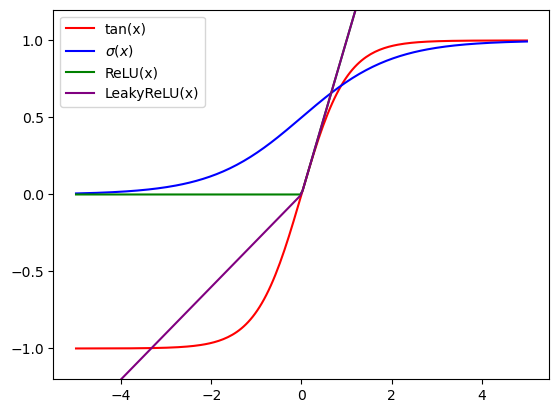

In [29]:
# ReLU and LeakyReLU plots
def leaky_relu(x, alpha=0.1):
    return max(alpha*x, x)
def leaky_reluP(x, alpha=0.1):
    if x > 0:
        return 1
    else:
        return alpha
    
relu_act = np.maximum(0, activation_input)
leaky_relu_act = np.maximum(0.3*activation_input, activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label='$\sigma(x)$')
sns.lineplot(x=activation_input, y=relu_act, color='green', label='ReLU(x)')
sns.lineplot(x=activation_input, y=leaky_relu_act, color='purple', label='LeakyReLU(x)')
plt.ylim(-1.2, 1.2)

<Axes: >

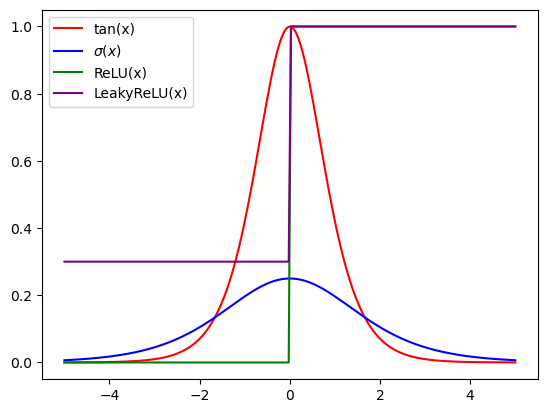

In [30]:
# Plot derivatives
relu_deriv = 1.0*(activation_input >0)
leaky_deriv = 1.0*(activation_input > 0) + 0.3*(activation_input <=0)

sns.lineplot(x=activation_input, y=tanh_deriv, color='red', label='tan(x)')
sns.lineplot(x=activation_input, y=sigmoid_deriv, color='blue', label='$\sigma(x)$')
sns.lineplot(x=activation_input, y=relu_deriv, color='green', label='ReLU(x)')
sns.lineplot(x=activation_input, y=leaky_deriv, color='purple', label='LeakyReLU(x)')

### Training with LeakyReLU activation

In [33]:
# Define the leak value
leak_rate = 0.1

# Define a FULLY CONNECTED NETWORK with LeakyReLU
fc_model_ReLU = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), # First hidden layer
    nn.LeakyReLU(),
    *[nn.Sequential(nn.Linear(n, n), nn.LeakyReLU()) for _ in range(5)],  # "list unpacking", each reamining layer has the same
                                                                     # input/output sizes.
    nn.Linear(n, classes)
)

For THE CNN model we define a `cnnLayer` function ot croeate combinations of `Conv2d` to make changes easier

In [40]:
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """ 
    in_filters: Number of channels going into the layer
    out_filters: Number of channels this layer should learn / ouptut, or "None" if we want the same number of channels as the input
    kernel_size: Size of the kernel
    """
    if out_filters is None:
        out_filters = in_filters  # A common pattern, now automated
        padding = kernel_size//2  # Padding to stay the same size
    return nn.Sequential(
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding),
        nn.LeakyReLU(leak_rate)
    ) 

In [52]:
# Create the CNN model with LeakyReLU
cnn_model_ReLU = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(2*n_filters,2*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.MaxPool2d((2, 2)),
    nn.Conv2d(2*n_filters,4*n_filters, 3, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(4*n_filters,4*n_filters, 3, padding=1),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes)
)

In [34]:
# Train the fully connected network with reLU
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = False  # False for training FC

fc_model_ReLU_results = train_network_EZA(fc_model_ReLU,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 30/30 [01:33<00:00,  3.13s/it]


In [53]:
# Train the CNN with ReLU

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run

torch.backends.cudnn.benchmark = True  # True for CNN training

# Train the Fully Connected Network baseline
cnn_model_ReLU_results = train_network_EZA(cnn_model_ReLU,
                                          loss_function,
                                          train_fmnist_loader,
                                          test_loader=test_fmnist_loader,
                                          epochs=30,
                                          score_funcs={'Accuracy': accuracy_score},
                                          device=device
)

Epoch: 100%|██████████| 30/30 [01:39<00:00,  3.30s/it]


(0.0, 10.0)

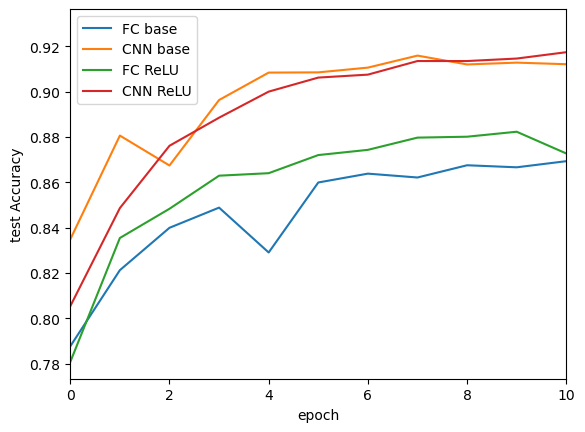

In [ ]:
# Plot results
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_base_results, label='FC base')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_base_results, label='CNN base')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_model_ReLU_results, label='FC ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_model_ReLU_results, label='CNN ReLU')
plt.xlim(0,30)


Try different batch sizes !!!!